# 07 - Descriptive Analysis

Exploratory data analysis of the assembled 15-minute bike-count/weather table
(`data/raw/model_table/model_table.csv`, built by `06_baseline_model.ipynb`
and **not** regenerated here). This notebook is deliberately *not* modeling:
no train/test split, no forecasting - only descriptive statistics and charts
describing what the data looks like, to inform feature engineering for later
modeling notebooks.

Questions answered below, each with concrete numbers (not just "see chart
above"):

1. Which station(s) are busiest / quietest, overall and by time period?
2. When is traffic busiest - hour of day, day of week, month? Do patterns
   differ by station (commuter vs. leisure stations)?
3. How does traffic relate to weather (temperature, precipitation, wind)?
4. How does traffic relate to public holidays, school holidays, and WWU
   lecture periods?

Every computation (ranking, grouping, weather-bucketed averages,
boolean-flag comparisons) lives in
`muenster_bike_forecast.analysis.descriptive`; this notebook only calls
those functions, loads data, and charts/narrates the results.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make `src/` importable regardless of whether this notebook is run from
# `notebooks/` (the normal case) or the project root.
_cwd = Path.cwd().resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from muenster_bike_forecast.analysis.descriptive import (
    DEFAULT_PRECIPITATION_BINS,
    DEFAULT_PRECIPITATION_LABELS,
    DEFAULT_TEMPERATURE_BINS,
    DEFAULT_TEMPERATURE_LABELS,
    DEFAULT_WIND_BINS,
    DEFAULT_WIND_LABELS,
    average_by_time_feature,
    average_by_time_feature_per_station,
    average_by_weather_bucket,
    compare_boolean_flag,
    rank_stations,
    rank_stations_by_group,
    weather_correlations,
)

MODEL_TABLE_PATH = PROJECT_ROOT / "data" / "raw" / "model_table" / "model_table.csv"
STATIONS_PATH = PROJECT_ROOT / "data" / "raw" / "bike_counts" / "stations.json"

In [2]:
# A small, fixed color palette (not matplotlib's default rainbow cycle):
# blue = primary / single-series / "above average", orange = secondary
# series (e.g. a weekend curve next to a weekday one), red = "below
# average". Kept consistent across every chart in this notebook.
COLOR_BLUE = "#2a78d6"
COLOR_ORANGE = "#eb6834"
COLOR_RED = "#e34948"
COLOR_GRID = "#e1e0d9"
COLOR_MUTED = "#898781"

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": COLOR_MUTED,
        "axes.grid": True,
        "grid.color": COLOR_GRID,
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "font.size": 10,
    }
)

## 0. Load data and station names

Reads the already-assembled `model_table.csv` and the station metadata in
`data/raw/bike_counts/stations.json` for human-readable names - the model
table itself only has a numeric `station_id`, no name/location.

In [3]:
df = pd.read_csv(MODEL_TABLE_PATH, parse_dates=["datetime"])

with open(STATIONS_PATH, encoding="utf-8") as f:
    station_meta = json.load(f)
station_names = {int(s["station_id"]): s["name"] for s in station_meta}

missing_names = set(df["station_id"].unique()) - set(station_names)
if missing_names:
    raise ValueError(f"No name found for station id(s): {sorted(missing_names)}")

df["station_name"] = df["station_id"].map(station_names)
df["is_weekend"] = df["day_of_week"] >= 5

# `join.py` documents bike-count timestamps as naive Europe/Berlin local
# time; the joined/model table keeps that convention (weather is as-of
# joined onto the naive local timestamp, not converted to UTC on output).
# Confirm that here rather than assuming it.
assert df["datetime"].dt.tz is None, "Expected naive (tz-unaware) datetimes."

n_null_count = int(df["total_count"].isna().sum())
print(f"{len(df):,} rows, {df['station_id'].nunique()} stations")
print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")
print(
    f"Null total_count rows: {n_null_count:,} "
    f"({100 * df['total_count'].isna().mean():.2f}%)"
)

2,337,596 rows, 23 stations
Date range: 2020-01-01 00:00:00 to 2026-07-06 04:45:00
Null total_count rows: 0 (0.00%)


`datetime` is confirmed tz-naive (Europe/Berlin local time, per
`src/muenster_bike_forecast/data/join.py`). The current data pull has
**zero rows with a null `total_count`**: a missing 15-minute interval shows
up further upstream as an entirely absent `(station_id, datetime)` row, not
as a `NaN` inside a present row. Every function in
`muenster_bike_forecast.analysis.descriptive` still explicitly drops
null-`total_count` rows before averaging rather than treating a gap as zero
traffic, so the numbers below stay correct even against a future data pull
that does carry `NaN`s.

In [4]:
coverage = (
    df.groupby("station_name")
    .agg(first_date=("datetime", "min"), last_date=("datetime", "max"), n_rows=("datetime", "size"))
    .sort_values("first_date")
)
coverage

,first_date,last_date,n_rows
station_name,,,
Hafenstraße,2020-01-01 00:00:00,2026-07-06 04:45:00,221612
"Kanalpromenade, Abschnitt 5",2023-01-01 00:00:00,2026-07-06 01:15:00,116310
Warendorfer Straße,2023-01-01 00:00:00,2026-07-06 01:45:00,119178
Promenade (nördl. Salzstraße),2023-01-01 00:00:00,2026-07-06 04:45:00,117463
Neutor,2023-01-01 00:00:00,2026-07-06 02:15:00,119168
Weseler Straße,2023-01-01 00:00:00,2026-07-06 04:45:00,119212
Hüfferstraße,2023-01-01 00:00:00,2026-07-06 04:45:00,118844
Hammer Straße,2023-01-01 00:00:00,2026-07-06 04:45:00,119296
Wolbecker Straße,2023-01-01 00:00:00,2026-07-06 04:45:00,120744


The 23 stations were **not all installed at the same time**: one station
(*Hafenstraße*) has data back to January 2020, ten stations start January
2023, and the remaining twelve (mostly the newer "Kanalpromenade" segments,
*Coesfelder Kreuz*, *Bismarckallee*, …) only start between late 2023 and
early 2024. Every ranking/average below uses each station's *own* full
history, so they should be read as "typical volume while that station has
been counting", not as a calendar-controlled comparison across stations.

## 1. Busiest and quietest stations

`rank_stations` ranks stations by mean 15-minute count over their full
history; `rank_stations_by_group` repeats the ranking separately for
weekdays and weekends to see whether the order changes.

In [5]:
overall_ranking = rank_stations(df, station_col="station_name")
overall_ranking

,rank,station_name,mean,median,n_obs
0,1,Promenade (nördl. Salzstraße),304.846982,260.0,117463
1,2,Neutor,221.049627,184.0,119168
2,3,Promenade (westl. Hals),190.148491,148.0,89756
3,4,Wolbecker Straße,161.339280,124.0,120744
4,5,Hammer Straße,149.825996,122.0,119296
5,6,Hafenstraße,134.350053,128.0,221612
6,7,Coesfelder Kreuz,127.306381,88.0,85658
7,8,Hüfferstraße,125.096311,86.0,118844
8,9,Warendorfer Straße,117.615785,90.0,119178
9,10,Bismarckallee,106.527508,72.0,41660


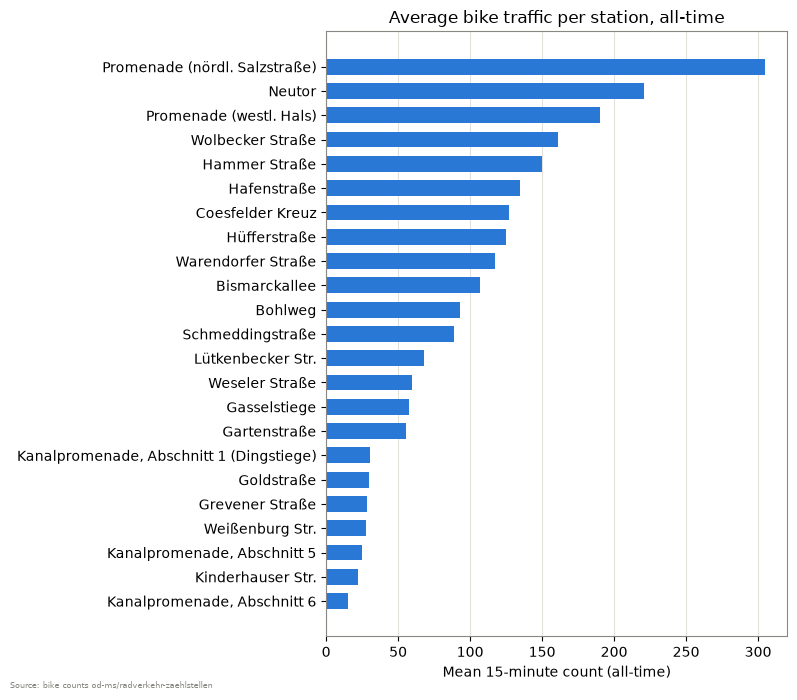

In [6]:
ordered = overall_ranking.sort_values("mean")
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(ordered["station_name"], ordered["mean"], color=COLOR_BLUE, height=0.65)
ax.set_xlabel("Mean 15-minute count (all-time)")
ax.set_title("Average bike traffic per station, all-time")
ax.grid(axis="y", visible=False)
fig.text(
    0.01, 0.01, "Source: bike counts od-ms/radverkehr-zaehlstellen",
    fontsize=6, color=COLOR_MUTED,
)
fig.tight_layout()
plt.show()

**Findings:** *Promenade (nördl. Salzstraße)* is by far the busiest station
(≈305 average 15-minute count), followed by *Neutor* (≈221) and
*Promenade (westl. Hals)* (≈190) - all three are central-city corridors.
The quietest station, *Kanalpromenade, Abschnitt 6* (≈15), sees roughly
**20x less traffic** than the busiest one. The 23 stations span a very wide
absolute-volume range, so any pooled model feature built on an absolute
threshold (e.g. "high-traffic day") needs to be station-relative, not a
single global cutoff.

In [7]:
weekday_weekend_ranking = rank_stations_by_group(
    df, period_col="is_weekend", station_col="station_name"
)

rank_pivot = weekday_weekend_ranking.pivot(
    index="station_name", columns="is_weekend", values="rank"
).rename(columns={False: "rank_weekday", True: "rank_weekend"})
rank_pivot["rank_change"] = rank_pivot["rank_weekday"] - rank_pivot["rank_weekend"]
rank_pivot.sort_values("rank_change", ascending=False)

is_weekend,rank_weekday,rank_weekend,rank_change
station_name,,,
"Kanalpromenade, Abschnitt 1 (Dingstiege)",20,17,3
"Kanalpromenade, Abschnitt 5",21,18,3
"Kanalpromenade, Abschnitt 6",23,21,2
Warendorfer Straße,9,7,2
Bismarckallee,10,9,1
Bohlweg,11,10,1
Gasselstiege,15,14,1
Hafenstraße,7,6,1
Neutor,2,2,0


**Findings:** the top 3 (*Promenade (nördl. Salzstraße)*, *Neutor*,
*Promenade (westl. Hals)*) hold the exact same rank on weekdays and
weekends - the city's main cycling corridors stay busiest regardless of day
type. The biggest *movers* are the three "Kanalpromenade" (canal-promenade)
segments, which each climb multiple ranks on weekends (a leisure-route
signature), while commuter-road stations such as *Weißenburg Str.* and
*Kinderhauser Str.* drop several ranks. This is a useful feature-engineering
signal in its own right: a station-level "weekend affinity"
(mean(weekend)/mean(weekday)) separates leisure routes from commuter routes
more cleanly than the raw ranking alone - explored further in section 2c.

## 2. When is traffic busiest?

### 2a. Hour of day, day of week, month (all stations pooled)

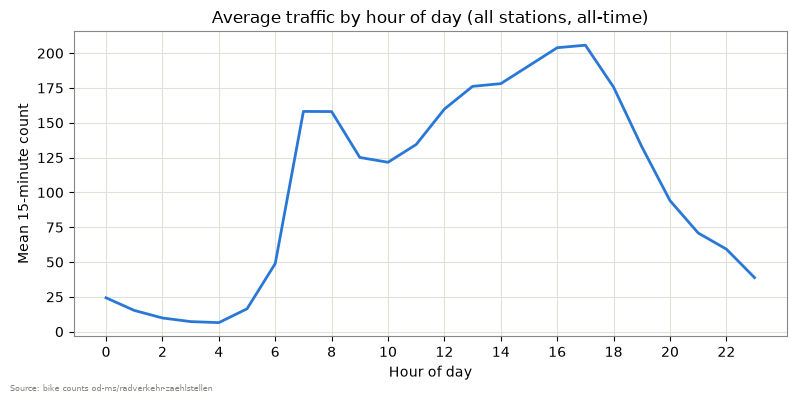

In [8]:
hourly = average_by_time_feature(df, time_col="hour")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hourly["hour"], hourly["mean"], color=COLOR_BLUE, linewidth=2)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean 15-minute count")
ax.set_title("Average traffic by hour of day (all stations, all-time)")
ax.set_xticks(range(0, 24, 2))
fig.text(
    0.01, 0.01, "Source: bike counts od-ms/radverkehr-zaehlstellen",
    fontsize=6, color=COLOR_MUTED,
)
fig.tight_layout()
plt.show()

**Findings:** pooled across all stations, traffic is clearly bimodal: a
morning peak around 07:00-08:00 (≈158) and a taller evening peak at 17:00
(≈206), with a trough around 03:00-04:00 (≈7, roughly 30x lower than the
evening peak). Midday (10:00-14:00) sits at a moderate plateau (≈122-178)
rather than a deep dip, hinting that the pooled curve already blends a
commuting pattern with a flatter, non-commuting one (see 2c).

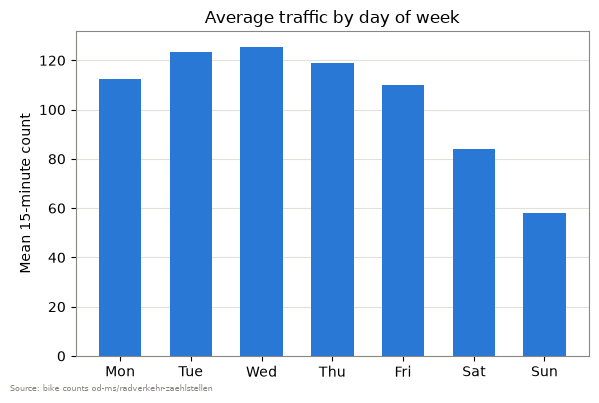

In [9]:
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_dow = average_by_time_feature(df, time_col="day_of_week")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dow_labels, by_dow["mean"], color=COLOR_BLUE, width=0.6)
ax.set_ylabel("Mean 15-minute count")
ax.set_title("Average traffic by day of week")
ax.grid(axis="x", visible=False)
fig.text(
    0.01, 0.01, "Source: bike counts od-ms/radverkehr-zaehlstellen",
    fontsize=6, color=COLOR_MUTED,
)
fig.tight_layout()
plt.show()

**Findings:** Monday-Friday sit in a narrow band (≈110-126), peaking
midweek on Tuesday (≈125.5). Traffic drops on Saturday (≈84, -34% vs. the
weekday average) and drops further on Sunday (≈58, -54% vs. Tuesday's
peak) - a clear, large weekday/weekend gap that any daily-seasonality
feature must capture.

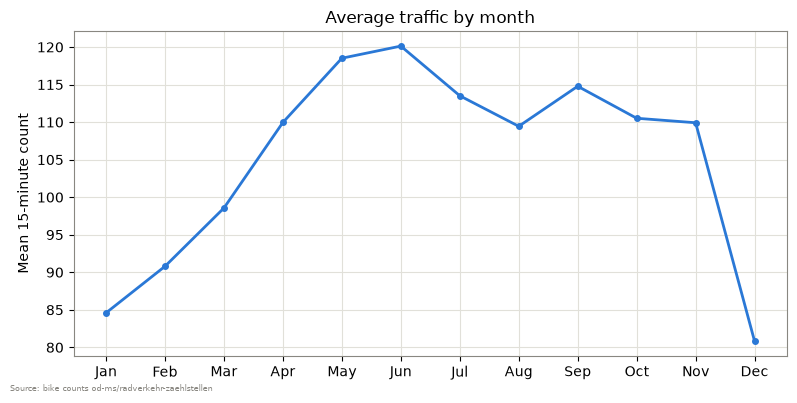

In [10]:
month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]
by_month = average_by_time_feature(df, time_col="month")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(month_labels, by_month["mean"], color=COLOR_BLUE, linewidth=2, marker="o", markersize=4)
ax.set_ylabel("Mean 15-minute count")
ax.set_title("Average traffic by month")
fig.text(
    0.01, 0.01, "Source: bike counts od-ms/radverkehr-zaehlstellen",
    fontsize=6, color=COLOR_MUTED,
)
fig.tight_layout()
plt.show()

**Findings:** traffic peaks in June (≈120) and bottoms out in
December/January (≈81 / ≈85) - a ≈33% seasonal swing from winter trough to
summer peak. Notably, July and August (≈114 / ≈109) dip slightly *below*
June despite being warmer on average - plausibly the WWU semester break and
summer school-holiday period (both checked in section 4) pulling volume
down even as weather improves, i.e. weather and calendar effects can pull
in opposite directions in the same month.

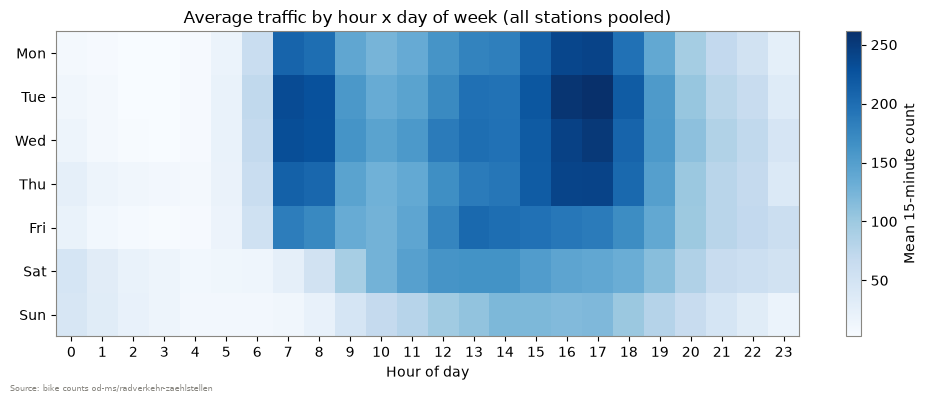

In [11]:
pivot_hour_dow = average_by_time_feature_per_station(
    df, time_col="hour", station_col="day_of_week"
)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot_hour_dow.values, aspect="auto", cmap="Blues")
ax.set_yticks(range(len(dow_labels)))
ax.set_yticklabels(dow_labels)
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_xlabel("Hour of day")
ax.set_title("Average traffic by hour x day of week (all stations pooled)")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Mean 15-minute count")
ax.grid(False)
fig.text(
    0.01, 0.01, "Source: bike counts od-ms/radverkehr-zaehlstellen",
    fontsize=6, color=COLOR_MUTED,
)
fig.tight_layout()
plt.show()

**Findings:** the weekday rows show two sharp vertical bands at the
morning (07:00-08:00) and evening (16:00-18:00) commute hours; the weekend
rows have no such bands and instead build gradually to a broad, lower
early-afternoon plateau. This hour x day-of-week interaction is exactly the
kind of pattern a purely additive `hour` + `day_of_week` model feature set
would miss - an explicit interaction term (or a combined
"hour-within-day-type" feature) is likely to help.

### 2c. Station-level profiles: commuter vs. leisure patterns

The pooled hour-of-day curve above blends 23 stations with very different
roles. Splitting the hourly average into weekday vs. weekend subsets, per
station, exposes two clearly distinct signatures.

In [12]:
weekday_df = df.loc[~df["is_weekend"]]
weekend_df = df.loc[df["is_weekend"]]

hourly_weekday_by_station = average_by_time_feature_per_station(
    weekday_df, time_col="hour", station_col="station_name"
)
hourly_weekend_by_station = average_by_time_feature_per_station(
    weekend_df, time_col="hour", station_col="station_name"
)

weekday_mean = rank_stations(weekday_df, station_col="station_name").set_index(
    "station_name"
)["mean"]
weekend_mean = rank_stations(weekend_df, station_col="station_name").set_index(
    "station_name"
)["mean"]
weekend_weekday_ratio = (weekend_mean / weekday_mean).sort_values().rename(
    "weekend_to_weekday_ratio"
)
weekend_weekday_ratio.to_frame()

,weekend_to_weekday_ratio
station_name,
Coesfelder Kreuz,0.421788
Hüfferstraße,0.490798
Kinderhauser Str.,0.524093
Bismarckallee,0.538734
Neutor,0.564000
Weseler Straße,0.571420
Gartenstraße,0.575838
Promenade (westl. Hals),0.579698
Schmeddingstraße,0.589787


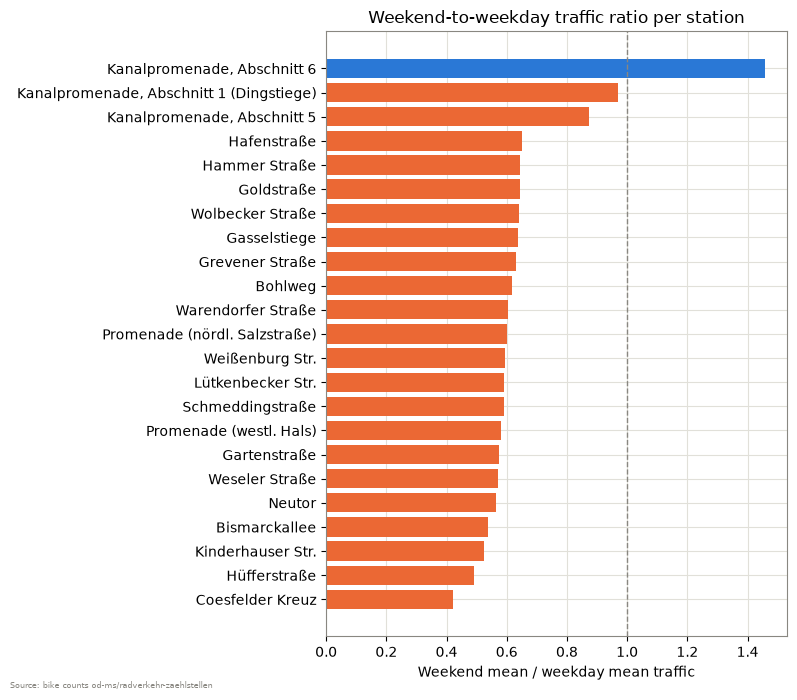

In [13]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = np.where(weekend_weekday_ratio.values >= 1.0, COLOR_BLUE, COLOR_ORANGE)
ax.barh(weekend_weekday_ratio.index, weekend_weekday_ratio.values, color=colors)
ax.axvline(1.0, color=COLOR_MUTED, linewidth=1, linestyle="--")
ax.set_xlabel("Weekend mean / weekday mean traffic")
ax.set_title("Weekend-to-weekday traffic ratio per station")
fig.text(
    0.01, 0.01, "Source: bike counts od-ms/radverkehr-zaehlstellen",
    fontsize=6, color=COLOR_MUTED,
)
fig.tight_layout()
plt.show()

**Findings:** *Kanalpromenade, Abschnitt 6* is the **only** station busier
on weekends than weekdays (ratio ≈1.46) - a clean leisure-route signature.
Every other station sees *less* weekend traffic, typically 42-65% of its
weekday volume; *Coesfelder Kreuz* is the most commuter-tilted (ratio
≈0.42). This single ratio is a strong, cheap per-station feature for
distinguishing commuter-dominated from leisure-dominated stations.

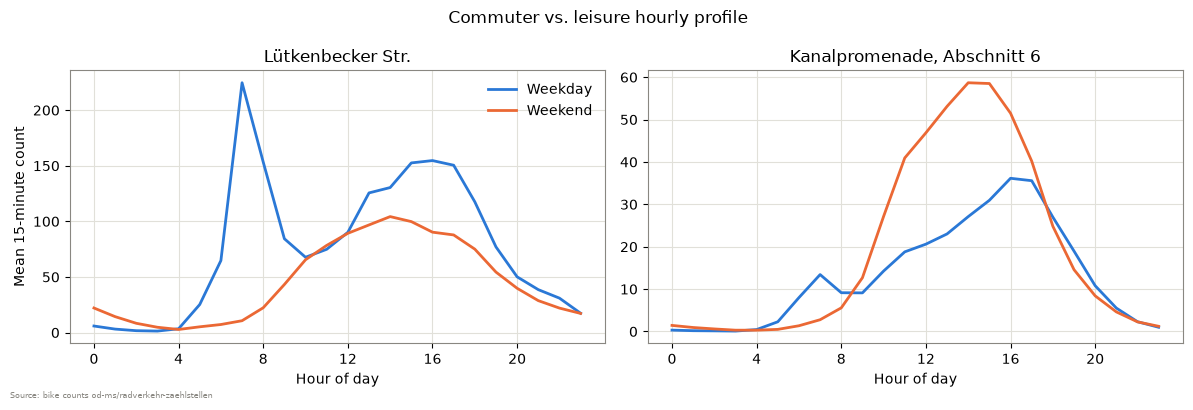

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
contrast_stations = ["Lütkenbecker Str.", "Kanalpromenade, Abschnitt 6"]

for ax, name in zip(axes, contrast_stations):
    ax.plot(
        hourly_weekday_by_station.columns,
        hourly_weekday_by_station.loc[name],
        color=COLOR_BLUE,
        linewidth=2,
        label="Weekday",
    )
    ax.plot(
        hourly_weekend_by_station.columns,
        hourly_weekend_by_station.loc[name],
        color=COLOR_ORANGE,
        linewidth=2,
        label="Weekend",
    )
    ax.set_title(name)
    ax.set_xlabel("Hour of day")
    ax.set_xticks(range(0, 24, 4))

axes[0].set_ylabel("Mean 15-minute count")
axes[0].legend(frameon=False)
fig.suptitle("Commuter vs. leisure hourly profile")
fig.text(
    0.01, 0.01, "Source: bike counts od-ms/radverkehr-zaehlstellen",
    fontsize=6, color=COLOR_MUTED,
)
fig.tight_layout()
plt.show()

**Findings:** *Lütkenbecker Str.* is the clearest commuter-pattern station
- its weekday morning peak (07:00-09:00) runs ≈46% above its own weekday
midday level (the largest such ratio of any station), with a matching
evening peak, and a much flatter, lower weekend curve. *Kanalpromenade,
Abschnitt 6* is the mirror image: a low, fairly flat weekday curve, but a
single broad weekend peak in the early afternoon (≈59 at 14:00 vs. ≈27 on
weekdays at the same hour) - textbook leisure/recreational-route behavior.
**Takeaway for modeling:** a global hour-of-day feature is a reasonable
default, but a per-station (or per-station-cluster) hour effect, or an
explicit commuter/leisure station flag derived from the weekend ratio
above, would likely add real signal.

## 3. Weather

`weather_correlations` gives the linear Pearson correlation of traffic with
each weather column (each computed pairwise-complete); `average_by_weather_bucket`
puts the same relationship in concrete terms - mean traffic per
weather-condition bucket, and how far that is from the overall mean.

In [15]:
weather_cols = [
    "weather_air_temperature_c",
    "weather_precipitation_mm",
    "weather_wind_speed_ms",
    "weather_relative_humidity_pct",
]
correlations = weather_correlations(df, weather_cols=weather_cols)
correlations

,weather_col,correlation,n_obs
0,weather_air_temperature_c,0.206392,2333691
1,weather_precipitation_mm,-0.033152,2334403
2,weather_wind_speed_ms,0.101527,2308465
3,weather_relative_humidity_pct,-0.288022,2330419


**Findings:** air temperature has the cleanest positive linear relationship
(r ≈ 0.21) and relative humidity the strongest linear relationship overall
(r ≈ -0.29, unsurprising since humid conditions co-occur with rain and cold).
Precipitation (r ≈ -0.03) and wind speed (r ≈ 0.10) look weak on paper - the
bucketed views below show why that number is misleading for precipitation
in particular.

In [16]:
temp_buckets = average_by_weather_bucket(
    df,
    weather_col="weather_air_temperature_c",
    bins=DEFAULT_TEMPERATURE_BINS,
    labels=DEFAULT_TEMPERATURE_LABELS,
)
temp_buckets

,bucket,mean,n_obs,pct_diff_from_overall
0,< 0°C,64.398664,129919,-38.400399
1,0-10°C,85.002601,936279,-18.692004
2,10-20°C,109.324564,992498,4.572815
3,20-30°C,172.562636,260904,65.062269
4,> 30°C,176.981761,14091,69.289319


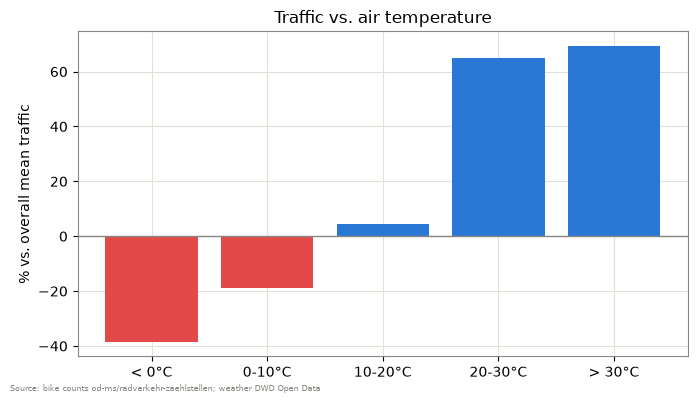

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = np.where(temp_buckets["pct_diff_from_overall"] >= 0, COLOR_BLUE, COLOR_RED)
ax.bar(temp_buckets["bucket"], temp_buckets["pct_diff_from_overall"], color=colors)
ax.axhline(0, color=COLOR_MUTED, linewidth=1)
ax.set_ylabel("% vs. overall mean traffic")
ax.set_title("Traffic vs. air temperature")
fig.text(
    0.01, 0.01,
    "Source: bike counts od-ms/radverkehr-zaehlstellen; weather DWD Open Data",
    fontsize=6, color=COLOR_MUTED,
)
fig.tight_layout()
plt.show()

**Findings:** temperature gives the cleanest weather signal in the whole
notebook - a monotonic staircase from **-38% below 0°C** to **+65% at
20-30°C** and **+69% above 30°C**, relative to the overall mean. This alone
is a strong forecasting feature candidate.

In [18]:
precip_buckets = average_by_weather_bucket(
    df,
    weather_col="weather_precipitation_mm",
    bins=DEFAULT_PRECIPITATION_BINS,
    labels=DEFAULT_PRECIPITATION_LABELS,
)
precip_buckets

,bucket,mean,n_obs,pct_diff_from_overall
0,dry (0-0.1mm),107.002852,2065326,2.374444
1,light (0.1-1mm),87.156785,204056,-16.613181
2,moderate (1-5mm),80.834579,61939,-22.661920
3,heavy (> 5mm),67.105775,3082,-35.796885


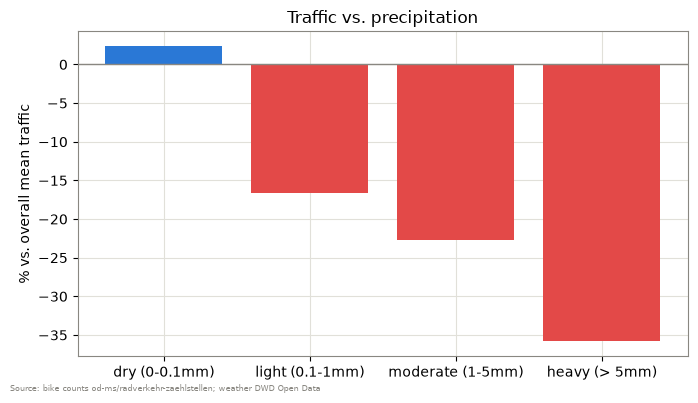

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = np.where(precip_buckets["pct_diff_from_overall"] >= 0, COLOR_BLUE, COLOR_RED)
ax.bar(precip_buckets["bucket"], precip_buckets["pct_diff_from_overall"], color=colors)
ax.axhline(0, color=COLOR_MUTED, linewidth=1)
ax.set_ylabel("% vs. overall mean traffic")
ax.set_title("Traffic vs. precipitation")
fig.text(
    0.01, 0.01,
    "Source: bike counts od-ms/radverkehr-zaehlstellen; weather DWD Open Data",
    fontsize=6, color=COLOR_MUTED,
)
fig.tight_layout()
plt.show()

**Findings:** traffic on dry 15-minute intervals (0-0.1mm) is close to the
overall average (+2%), but falls to **-17%** on light rain (0.1-1mm),
**-23%** on moderate rain (1-5mm), and **-36%** on heavy rain (>5mm, only
≈0.13% of rows but directionally consistent with the lighter buckets). The
raw correlation (-0.03) badly understates this because ~88% of all 15-minute
intervals have zero recorded precipitation, so most of the variance in
`total_count` at zero precipitation swamps a small, real, tail effect. **A
bucketed/threshold precipitation feature is a better modeling choice than
the raw millimeter value on its own.**

In [20]:
wind_buckets = average_by_weather_bucket(
    df,
    weather_col="weather_wind_speed_ms",
    bins=DEFAULT_WIND_BINS,
    labels=DEFAULT_WIND_LABELS,
)
wind_buckets

,bucket,mean,n_obs,pct_diff_from_overall
0,calm (0-3m/s),89.879063,1232890,-13.791407
1,moderate (3-6m/s),123.178177,837860,18.147842
2,brisk (6-10m/s),113.378872,223413,8.748721
3,strong (> 10m/s),92.838904,14302,-10.952439


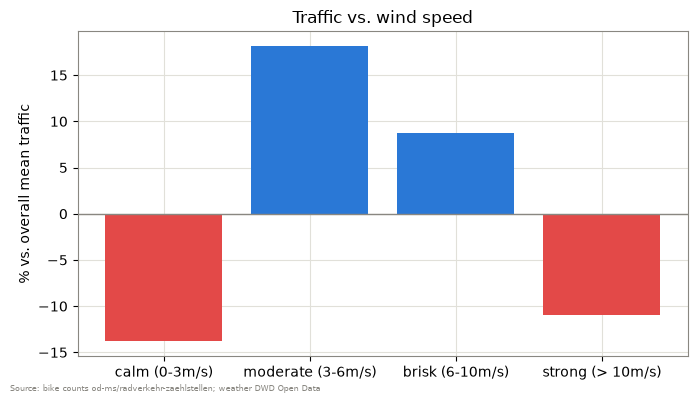

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = np.where(wind_buckets["pct_diff_from_overall"] >= 0, COLOR_BLUE, COLOR_RED)
ax.bar(wind_buckets["bucket"], wind_buckets["pct_diff_from_overall"], color=colors)
ax.axhline(0, color=COLOR_MUTED, linewidth=1)
ax.set_ylabel("% vs. overall mean traffic")
ax.set_title("Traffic vs. wind speed")
fig.text(
    0.01, 0.01,
    "Source: bike counts od-ms/radverkehr-zaehlstellen; weather DWD Open Data",
    fontsize=6, color=COLOR_MUTED,
)
fig.tight_layout()
plt.show()

**Findings:** wind is the odd one out - traffic is *lowest* in calm
conditions (0-3m/s, -14%) and *highest* at moderate wind (3-6m/s, +18%),
dropping again at strong wind (>10m/s, -11%). This is **not** read as "some
wind helps cycling"; it is much more likely confounded with time-of-day and
season (calm conditions are common overnight and during winter high-pressure
spells, both already low-traffic periods on their own). **Caution for
modeling:** do not feed raw wind speed in as a linear predictor expecting a
clean effect - if used at all, it should be combined with or evaluated
alongside hour-of-day/season controls rather than on its own.

## 4. Calendar flags: public holidays, school holidays, lecture periods

`compare_boolean_flag` compares mean traffic when each flag is true vs.
false. Because public and school holidays fall overwhelmingly on days that
would otherwise be weekdays, each flag is also compared **restricted to
weekdays only**, to separate the calendar effect from the weekday/weekend
effect already covered in section 2.

In [22]:
calendar_flags = ["is_public_holiday", "is_school_holiday", "is_lecture_period"]

flag_rows = []
for flag in calendar_flags:
    overall = compare_boolean_flag(df, flag)
    weekday_only = compare_boolean_flag(weekday_df, flag)
    flag_rows.append({"flag": flag, "subset": "all days", **overall})
    flag_rows.append({"flag": flag, "subset": "weekdays only", **weekday_only})

flag_summary = pd.DataFrame(flag_rows)
flag_summary

,flag,subset,mean_true,mean_false,pct_difference,n_true,n_false
0,is_public_holiday,all days,54.140125,106.236288,-49.038011,75932,2261664
1,is_public_holiday,weekdays only,54.487384,120.874708,-54.922428,71972,1597602
2,is_school_holiday,all days,92.114453,107.977467,-14.691040,505953,1831643
3,is_school_holiday,weekdays only,100.281183,123.196479,-18.600610,377669,1291905
4,is_lecture_period,all days,106.715504,101.095820,5.558770,1434346,903250
5,is_lecture_period,weekdays only,120.531507,113.831173,5.886202,1041989,627585


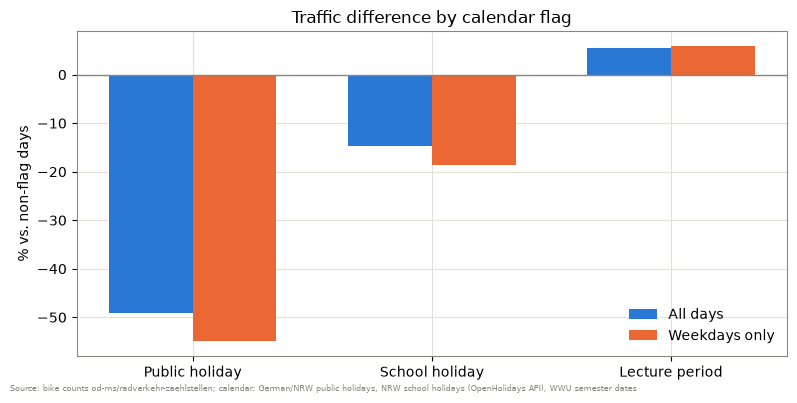

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(calendar_flags))
width = 0.35
all_days = flag_summary.loc[flag_summary["subset"] == "all days", "pct_difference"].values
weekdays_only = flag_summary.loc[
    flag_summary["subset"] == "weekdays only", "pct_difference"
].values
ax.bar(x - width / 2, all_days, width, label="All days", color=COLOR_BLUE)
ax.bar(x + width / 2, weekdays_only, width, label="Weekdays only", color=COLOR_ORANGE)
ax.axhline(0, color=COLOR_MUTED, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(["Public holiday", "School holiday", "Lecture period"])
ax.set_ylabel("% vs. non-flag days")
ax.legend(frameon=False)
ax.set_title("Traffic difference by calendar flag")
fig.text(
    0.01, 0.01,
    "Source: bike counts od-ms/radverkehr-zaehlstellen; calendar: German/NRW "
    "public holidays, NRW school holidays (OpenHolidays API), WWU semester dates",
    fontsize=6, color=COLOR_MUTED,
)
fig.tight_layout()
plt.show()

**Findings:**

- `is_public_holiday`: **-49%** overall, **-55%** restricted to weekdays -
  the single largest effect found in this notebook, larger even than the
  plain weekend effect (-34% Saturday / -54% Sunday, section 2a). Public
  holidays behave like an "extra Sunday", regardless of which weekday they
  land on.
- `is_school_holiday`: **-15%** overall, **-19%** weekdays-only - a real
  but more moderate drop, consistent with fewer school-commute trips.
- `is_lecture_period`: **+5.6%** overall, **+5.9%** weekdays-only - small
  but positive and consistent in both subsets, plausibly WWU students
  commuting by bike during term time. Note lecture periods are themselves
  correlated with month (WS ≈ Oct-Feb, SS ≈ Apr-Jul), so in a model this
  feature should be allowed to compete with `month` for signal rather than
  assumed to add on top of it.

## Summary / Key Insights

- **Station volume varies enormously** (~20x between the busiest,
  *Promenade (nördl. Salzstraße)* at ≈305 avg. count, and the quietest,
  *Kanalpromenade, Abschnitt 6* at ≈15). Any global/absolute traffic
  threshold should be station-relative, not a single cutoff.
- **The busiest-3 ranking is stable** across weekdays vs. weekends, but a
  handful of stations - especially the "Kanalpromenade" canal-promenade
  segments - climb several ranks on weekends, marking them as leisure
  routes rather than commuter routes.
- **Weekend/weekday traffic ratio is a strong, cheap per-station feature**
  for a commuter-vs-leisure flag: every station except
  *Kanalpromenade, Abschnitt 6* (ratio ≈1.46, uniquely weekend-heavy) sees
  less weekend traffic, typically 42-65% of its weekday volume
  (*Coesfelder Kreuz* is most commuter-tilted at ≈0.42).
- **Hour-of-day x day-of-week interacts strongly**: weekday traffic is
  sharply bimodal (peaks ≈08:00 and ≈17:00), weekend traffic is a single
  broad early-afternoon plateau - a purely additive `hour` + `day_of_week`
  feature pair would miss this; an explicit interaction feature is likely
  worth adding.
- **Day-of-week and month effects are both large**: Sunday traffic is ≈54%
  below Tuesday's weekly peak; June (summer peak) is ≈33% higher than
  December/January (winter trough).
- **Temperature is the cleanest weather signal**: a monotonic swing from
  -38% (below 0°C) to +65-69% (above 20°C) relative to the overall mean,
  correlation r ≈ 0.21.
- **Precipitation's effect is real but concentrated in the tail, and the
  raw correlation (r ≈ -0.03) badly understates it**: traffic on heavy-rain
  intervals (>5mm) is ≈36% below the overall mean, vs. roughly average on
  dry intervals - a bucketed/threshold precipitation feature will likely
  outperform a raw linear term.
- **Wind speed shows a non-monotonic, likely confounded relationship**
  (moderate wind reads *busier* than calm) - treat with caution; it should
  not be used as a naive linear predictor without controlling for
  time-of-day/season.
- **Public holidays are the single largest categorical effect found**
  (-55% on what would otherwise be a weekday) - larger than the weekend
  effect itself. School holidays are a smaller but real -19% (weekdays
  only); WWU lecture periods are a small, consistent +5.9% (weekdays only)
  but correlate with month and should compete with it for signal in a
  model rather than being assumed additive.
- **Data-coverage caveat**: the 23 stations were installed at different
  times (one since 2020, ten since 2023, twelve more only from late
  2023/2024 onward), so cross-station comparisons above use each station's
  own full history and are not perfectly calendar-controlled.

## 5. Station locations

Station coordinates are not part of the source data - `stations.json` has
only a `station_id` and a human-readable `name`, no lat/lon. They are
resolved here via the OpenStreetMap Nominatim search API
(`muenster_bike_forecast.data.geocode.geocode_stations`), qualifying every
station name with ", Münster, Germany" and checking each result against a
Münster city bounding box before accepting it. Results are cached to
`data/raw/bike_counts/station_locations.csv`, so a fresh `Restart & Run All`
only re-hits the network for station ids not already in that file (none,
normally - the cache is already populated).

**All 23 stations resolved to a coordinate within Münster's city bounds.**
Six of them do not geocode cleanly on their exact name and use a manually
chosen, documented fallback query instead - these are approximations of
the true sensor location, not exact matches, and are marked `(approx.)` on
the map below:

- Three "Kanalpromenade" canal-promenade path segments - *Kanalpromenade,
  Abschnitt 1 (Dingstiege)*, *Abschnitt 5*, *Abschnitt 6* - do not geocode
  as a single point via their own name. Segment 1 uses its own
  parenthetical cross-street ("Dingstiege"); segments 5 and 6 have no
  cross-street in their name and fall back to the general "Kanalpromenade,
  Münster, Germany" query, so they share one approximate point.
- *Lütkenbecker Str.* - the abbreviated street name has no Nominatim match;
  the unabbreviated district name it is named after ("Lütkenbeck") does.
- *Promenade (nördl. Salzstraße)* and *Promenade (westl. Hals)* - both
  station names describe a position *relative to* a nearby place rather
  than a geocodable address on their own, so are geocoded via that
  cross-reference ("Salzstraße" / "Hals") instead.

In [24]:
from muenster_bike_forecast.data.geocode import build_geocode_query, geocode_stations

STATION_LOCATIONS_PATH = (
    PROJECT_ROOT / "data" / "raw" / "bike_counts" / "station_locations.csv"
)

stations_for_geocoding = pd.DataFrame(
    [{"station_id": s["station_id"], "name": s["name"]} for s in station_meta]
)
name_by_id = stations_for_geocoding.set_index("station_id")["name"].to_dict()

# Documented, manually-chosen fallback queries for the six station names
# that do not geocode cleanly on their own (see markdown above).
GEOCODE_QUERY_OVERRIDES = {
    "300037544": "Dingstiege, Münster, Germany",
    "100053305": "Kanalpromenade, Münster, Germany",
    "300037936": "Kanalpromenade, Münster, Germany",
    "300037920": "Lütkenbeck, Münster, Germany",
    "100031297": "Salzstraße, Münster, Germany",
    "300037405": "Hals, Münster, Germany",
}

# Idempotent: only station ids missing from STATION_LOCATIONS_PATH trigger
# a (rate-limited, 1 req/sec) Nominatim request; a populated cache makes
# this a pure disk read with zero network calls.
locations = geocode_stations(
    stations_for_geocoding, STATION_LOCATIONS_PATH, query_overrides=GEOCODE_QUERY_OVERRIDES
)
locations["is_approximated"] = [
    query != build_geocode_query(name_by_id[station_id])
    for station_id, query in zip(locations["station_id"], locations["geocode_query"])
]

n_resolved = int(locations["resolved"].sum())
n_approximated = int(locations["is_approximated"].sum())
print(f"{n_resolved}/{len(locations)} stations resolved within Münster bounds")
print(f"{n_approximated} station(s) used an approximated/fallback query")

unresolved = locations.loc[~locations["resolved"]]
if not unresolved.empty:
    print("Unresolved (needs manual placement):")
    print(unresolved[["station_id", "name", "geocode_query"]].to_string(index=False))

locations

23/23 stations resolved within Münster bounds
6 station(s) used an approximated/fallback query


,station_id,name,lat,lon,geocode_query,resolved,is_approximated
0,100020113,Wolbecker Straße,51.952458,7.664111,"Wolbecker Straße, Münster, Germany",True,False
1,100031297,Promenade (nördl. Salzstraße),51.959951,7.633835,"Salzstraße, Münster, Germany",True,True
2,100031300,Hafenstraße,51.953651,7.632844,"Hafenstraße, Münster, Germany",True,False
3,100034978,Gartenstraße,51.968414,7.641068,"Gartenstraße, Münster, Germany",True,False
4,100034980,Hammer Straße,51.954340,7.626078,"Hammer Straße, Münster, Germany",True,False
5,100034981,Weseler Straße,51.949502,7.616697,"Weseler Straße, Münster, Germany",True,False
6,100034982,Hüfferstraße,51.960156,7.603957,"Hüfferstraße, Münster, Germany",True,False
7,100034983,Warendorfer Straße,51.965591,7.652596,"Warendorfer Straße, Münster, Germany",True,False
8,100035541,Neutor,51.969583,7.607885,"Neutor, Münster, Germany",True,False
9,100053305,"Kanalpromenade, Abschnitt 5",51.959452,7.662429,"Kanalpromenade, Münster, Germany",True,True


Also copied to `data/processed/station_locations.csv` -- unlike the raw-data
cache above, `data/raw/*` is gitignored, but this small (23-row) derived
artifact is committed directly since the Streamlit dashboard needs it at
runtime to plot the live station map (see `app.py`).

In [ ]:
PROCESSED_LOCATIONS_PATH = PROJECT_ROOT / "data" / "processed" / "station_locations.csv"
PROCESSED_LOCATIONS_PATH.parent.mkdir(exist_ok=True)
locations.to_csv(PROCESSED_LOCATIONS_PATH, index=False)
print(
    f"Copied station locations -> "
    f"{PROCESSED_LOCATIONS_PATH.relative_to(PROJECT_ROOT)}"
)

In [25]:
station_ranking = rank_stations(df, station_col="station_id")
station_ranking["station_id"] = station_ranking["station_id"].astype(str)

map_data = locations.merge(station_ranking[["station_id", "mean"]], on="station_id", how="left")
map_data["station_name"] = map_data["station_id"].map(name_by_id)

missing_ranking = map_data.loc[map_data["mean"].isna(), "station_id"].tolist()
if missing_ranking:
    raise ValueError(f"No traffic ranking found for station id(s): {missing_ranking}")

# Rough distance from the city center (Prinzipalmarkt/Dom area), purely to
# check whether busier stations cluster centrally - not used as a model
# feature. 1 degree latitude =~ 111km everywhere; 1 degree longitude
# shrinks by cos(latitude) at this latitude (~52°N).
CENTER_LAT, CENTER_LON = 51.9625, 7.6256
map_data["dist_from_center_km"] = np.sqrt(
    ((map_data["lat"] - CENTER_LAT) * 111) ** 2
    + ((map_data["lon"] - CENTER_LON) * 111 * np.cos(np.radians(CENTER_LAT))) ** 2
)

center_traffic_corr = map_data["dist_from_center_km"].corr(map_data["mean"])
print(f"Correlation(distance from center, mean traffic) = {center_traffic_corr:.2f}")

map_data.sort_values("mean", ascending=False)[
    ["station_name", "mean", "lat", "lon", "dist_from_center_km", "is_approximated"]
]

Correlation(distance from center, mean traffic) = -0.51


,station_name,mean,lat,lon,dist_from_center_km,is_approximated
1,Promenade (nördl. Salzstraße),304.846982,51.959951,7.633835,0.630309,True
8,Neutor,221.049627,51.969583,7.607885,1.444359,False
10,Promenade (westl. Hals),190.148491,51.957057,7.624685,0.607386,True
0,Wolbecker Straße,161.339280,51.952458,7.664111,2.860150,False
4,Hammer Straße,149.825996,51.954340,7.626078,0.906362,False
2,Hafenstraße,134.350053,51.953651,7.632844,1.100134,False
21,Coesfelder Kreuz,127.306381,51.964597,7.599428,1.805126,False
6,Hüfferstraße,125.096311,51.960156,7.603957,1.502990,False
7,Warendorfer Straße,117.615785,51.965591,7.652596,1.877993,False
20,Bismarckallee,106.527508,51.955787,7.617090,0.945524,False


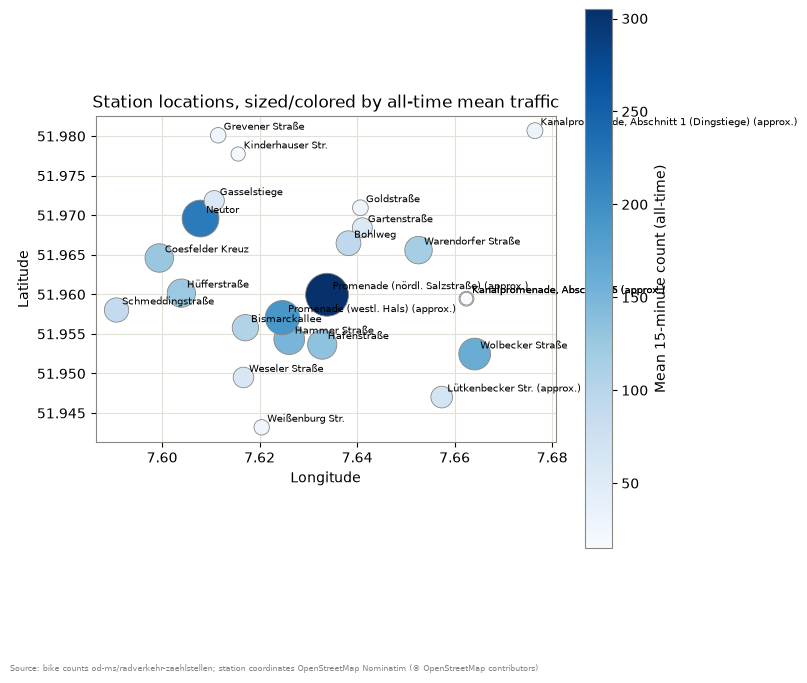

In [26]:
fig, ax = plt.subplots(figsize=(8, 8))
sizes = 40 + 3 * map_data["mean"]
scatter = ax.scatter(
    map_data["lon"],
    map_data["lat"],
    s=sizes,
    c=map_data["mean"],
    cmap="Blues",
    edgecolors=COLOR_MUTED,
    linewidths=0.6,
    zorder=3,
)
for _, row in map_data.iterrows():
    label = row["station_name"] + (" (approx.)" if row["is_approximated"] else "")
    ax.annotate(
        label,
        (row["lon"], row["lat"]),
        fontsize=7,
        xytext=(4, 4),
        textcoords="offset points",
    )

# No basemap/tile library is a project dependency yet (see CLAUDE.md); a
# plain lon/lat scatter is sufficient to see relative station positions.
# set_aspect corrects for longitude-degree compression at this latitude
# (~52°N) so the layout is not visibly stretched east-west.
ax.set_aspect(1 / np.cos(np.radians(CENTER_LAT)))
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Station locations, sized/colored by all-time mean traffic")
cbar = fig.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label("Mean 15-minute count (all-time)")
fig.text(
    0.01,
    0.01,
    "Source: bike counts od-ms/radverkehr-zaehlstellen; "
    "station coordinates OpenStreetMap Nominatim (© OpenStreetMap contributors)",
    fontsize=6,
    color=COLOR_MUTED,
)
fig.tight_layout()
plt.show()

**Findings:** the busiest stations cluster geographically toward the
**central city / Altstadt ring**, not the periphery. The top 3 -
*Promenade (nördl. Salzstraße)*, *Neutor*, *Promenade (westl. Hals)* -
and *Hammer Straße* / *Hafenstraße* (both top-6) all sit within roughly
1.4km of the Prinzipalmarkt/Dom city center, on the historic Promenade
ring or its immediate approaches. The quietest stations - the three
"Kanalpromenade" canal-promenade segments, *Kinderhauser Str.*, *Grevener
Straße*, *Weißenburg Str.* - sit further out (2-4km from center), on
outer/peripheral routes rather than the central ring. This gives a
moderate negative correlation between distance-from-center and mean
traffic (**r ≈ -0.51**, printed above): geography is a real, if partial,
signal - a station's ring-road vs. peripheral position looks like a
plausible engineered feature, though *Wolbecker Straße* (rank 4, ≈2.9km
out) and *Lütkenbecker Str.* (rank 13, ≈2.8km out) are notable exceptions
that keep the relationship from being a clean cutoff. The three
approximated "Kanalpromenade" points (marked `(approx.)` above) should be
read as "this general area of the canal promenade", not an exact sensor
pin - two of them (*Abschnitt 5* and *6*) share one fallback coordinate
and are not actually co-located.

### 5b. Station locations on a real street map

The lon/lat scatter above is useful for the distance-from-center
computation, but is not immediately recognizable as Münster to a human
reader. `plotly`'s `scatter_map` renders the same station/traffic data on
actual OpenStreetMap tiles (streets, place names, the river/canal) - no API
key needed, and it stays interactive (pan/zoom) when the notebook is opened
in Jupyter.

In [27]:
import plotly.express as px

street_map_data = map_data.copy()
street_map_data["label"] = street_map_data["station_name"] + street_map_data[
    "is_approximated"
].map({True: " (approx.)", False: ""})

# "YlOrRd" (yellow-orange-red) instead of a blue scale: OpenStreetMap tiles
# already render water features in light blue, so blue markers blend into
# the canal/river on the map (this city has several canal-side stations) -
# yellow-orange-red stays high-contrast against the map's whites/greens/
# blues at every traffic level, including the lightest end of the scale.
street_fig = px.scatter_map(
    street_map_data,
    lat="lat",
    lon="lon",
    size="mean",
    color="mean",
    color_continuous_scale="YlOrRd",
    hover_name="label",
    hover_data={"lat": False, "lon": False, "mean": ":.1f"},
    zoom=11.3,
    center={"lat": CENTER_LAT, "lon": CENTER_LON},
    height=650,
    map_style="open-street-map",
)
street_fig.update_traces(marker={"opacity": 0.9})
street_fig.update_layout(
    title=(
        "Station locations on OpenStreetMap, sized/colored by all-time "
        "mean traffic"
    ),
    coloraxis_colorbar_title="Mean 15-min count",
    margin={"l": 0, "r": 0, "t": 40, "b": 0},
    annotations=[
        {
            "text": (
                "Source: bike counts od-ms/radverkehr-zaehlstellen; station "
                "coordinates OpenStreetMap Nominatim; map tiles "
                "© OpenStreetMap contributors"
            ),
            "showarrow": False,
            "xref": "paper",
            "yref": "paper",
            "x": 0.0,
            "y": 0.0,
            "xanchor": "left",
            "yanchor": "bottom",
            "font": {"size": 9, "color": COLOR_MUTED},
            "bgcolor": "rgba(255,255,255,0.6)",
        }
    ],
)
street_fig.show()